### **Importação das Bibliotecas**
O primeiro passo é sempre importar as bibliotecas necessárias. No Colab, pandas e matplotlib já estão instaladas.

> Aluno: João Gabriel Santos Maciel de Carvalho. 202502411057 -- Atividade 2

In [2]:
# ── Importações ──────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


### **Criação e população do Dataset**
Vamos gerar um dataset realista com 50 registros de vendas de uma livraria e salvá-lo como arquivo CSV.

In [3]:
# ── Criação do Dataset ───────────────────────────────
np.random.seed(20)

produtos = {
    "Dom Casmurro":       ("Literatura", 35.90),
    "O Pequeno Príncipe": ("Infantil",   29.90),
    "Sapiens":            ("Ciências",   54.90),
    "Python para Dados":  ("Tecnologia", 89.90),
    "Clean Code":         ("Tecnologia", 95.00),
    "Harry Potter Vol.1": ("Fantasia",   49.90),
    "Atomic Habits":      ("Autoajuda",  44.90),
    "A Arte da Guerra":   ("Filosofia",  32.00),
    "Cosmos":             ("Ciências",   62.50),
    "Cem Anos de Solidão":("Literatura", 39.90),
    "A Grande Marcha":    ("Literatura", None),
    "O Iluminado":        ("Terror", None),
    "Vidas Secas":        ("Drama", None),
    "Tutorial Mestre":    ("Tecnologia", None),
    "Zimbabwe em Guerra": ("Política", None),
}

vendedores = ["Ana Lima", "Carlos Mendes", "Bruno Costa", "Fernanda Rocha"]
regioes    = ["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"]
datas      = pd.date_range("2024-01-01", "2024-06-30", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

rand_pricel = [25.60,34.10,8.76,12.20,20.00]

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

df.dropna()

# Salva como CSV
df.to_csv("vendas_livraria.csv", index=False)

print(f"✅ Dataset criado! Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
df.head()

✅ Dataset criado! Shape: (50, 9)
   Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']


,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2024-01-01,Python para Dados,Tecnologia,4,89.9,Fernanda Rocha,Centro-Oeste,359.6
1,2,2024-01-04,A Grande Marcha,Literatura,2,NaN,Bruno Costa,Norte,NaN
2,3,2024-01-08,Vidas Secas,Drama,1,NaN,Bruno Costa,Nordeste,NaN
3,4,2024-01-12,A Grande Marcha,Literatura,4,NaN,Fernanda Rocha,Sul,NaN
4,5,2024-01-15,Cem Anos de Solidão,Literatura,1,39.9,Carlos Mendes,Sul,39.9


### **Explorando o dataset (EDA)**
Antes de analisar, precisamos entender a estrutura e a qualidade dos dados.

In [4]:
# ── Exploração Inicial ───────────────────────────────
df = pd.read_csv("vendas_livraria.csv")

print("═" * 45)
print("📋 INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n📊 TIPOS DE DADOS:")
print(df.dtypes)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
📋 INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

📊 TIPOS DE DADOS:
id_venda         int64
data            object
produto         object
categoria       object
quantidade       int64
preco_unit     float64
vendedor        object
regiao          object
total_venda    float64
dtype: object

🔍 VALORES NULOS:
id_venda        0
data            0
produto         0
categoria       0
quantidade      0
preco_unit     22
vendedor        0
regiao          0
total_venda    22
dtype: int64

📈 ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,28.00,28.00
mean,3.08,52.43,161.36
std,1.38,19.69,107.97
min,1.00,32.00,39.90
25%,2.00,39.90,103.25
50%,3.00,44.90,139.15
75%,4.00,54.90,181.58
max,5.00,95.00,449.50


### **Análise das vendas**
Agora vamos responder perguntas de negócio usando agrupamentos e cálculos com pandas.

In [5]:
# ── Análise de Vendas ────────────────────────────────

# 1. Total faturado
total = df["total_venda"].sum()
print(f"💰 Faturamento Total: R$ {total:,.2f}")

# 2. Faturamento por categoria
print("\n📦 Faturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

# 3. Melhor vendedor
print("\n🏆 Ranking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

# 4. Produto mais vendido (em quantidade)
print("\n📚 Top 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

# 5. Venda média por região
print("\n🗺️  Ticket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

💰 Faturamento Total: R$ 4,518.20

📦 Faturamento por Categoria:
categoria
Tecnologia    R$ 1,633.50
Literatura    R$ 1,013.30
Autoajuda       R$ 718.40
Fantasia        R$ 499.00
Ciências        R$ 462.00
Filosofia       R$ 192.00
Drama             R$ 0.00
Política          R$ 0.00
Terror            R$ 0.00
Name: total_venda, dtype: object

🏆 Ranking de Vendedores:
vendedor
Carlos Mendes     R$ 1,725.70
Bruno Costa       R$ 1,159.10
Fernanda Rocha    R$ 1,112.80
Ana Lima            R$ 520.60
Name: total_venda, dtype: object

📚 Top 3 Produtos (qtd vendida):
produto
A Grande Marcha    25
O Iluminado        17
Dom Casmurro       16
Name: quantidade, dtype: int64

🗺️  Ticket Médio por Região:
regiao
Sudeste         R$ 247.20
Nordeste        R$ 186.35
Centro-Oeste    R$ 171.52
Norte           R$ 144.06
Sul              R$ 94.04
Name: total_venda, dtype: object


### Visualizações com Matplotlib
Dados falam melhor através de gráficos. Vamos criar 3 visualizações para comunicar os insights encontrados.

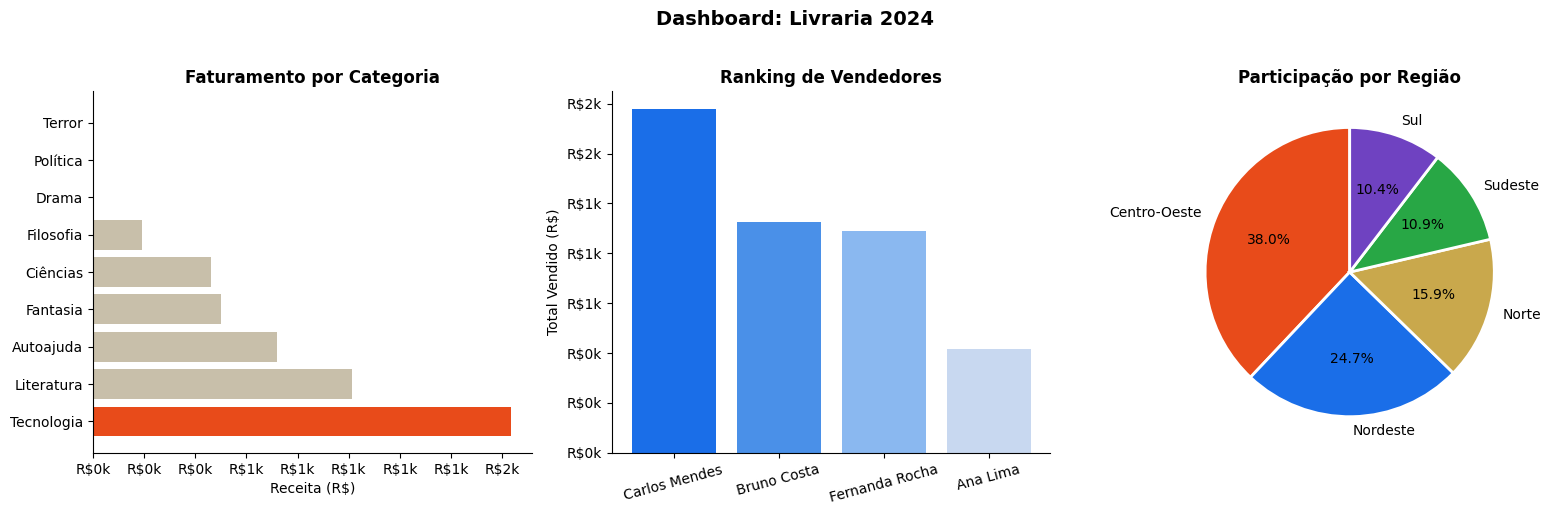

✅ Gráficos salvos em dashboard_livraria.png


In [6]:
# ── Visualizações ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

# --- Gráfico 1: Faturamento por Categoria (barras) ---
ax1 = axes[0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

# --- Gráfico 2: Ranking Vendedores (barras verticais) ---
ax2 = axes[1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

# --- Gráfico 3: Distribuição das Regiões (pizza) ---
ax3 = axes[2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficos salvos em dashboard_livraria.png")

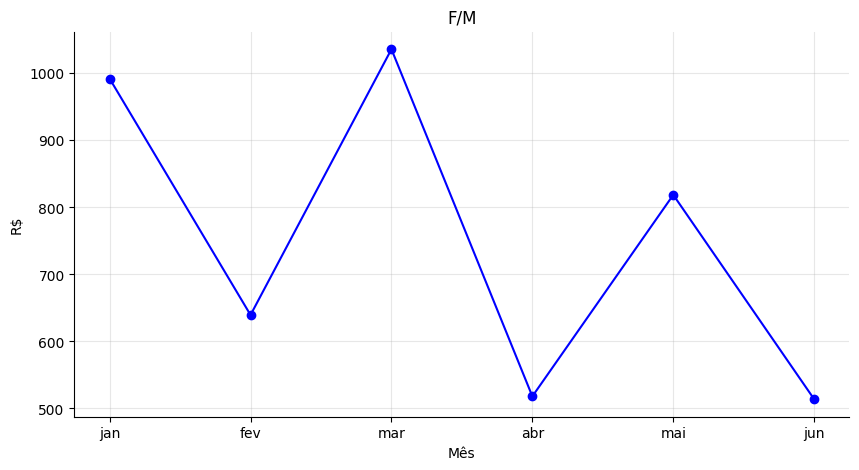

In [24]:
# Questão 1)

df["mes"] = pd.to_datetime(df["data"]).dt.month
ft_mens = df.groupby("mes")["total_venda"].sum()
plt.figure()
plt.plot(ft_mens.index, ft_mens.values, marker="o", color="#0000ff")
plt.title("F/M")
plt.xlabel("Mês")
plt.ylabel("R$")
plt.xticks(range(1,7), ["jan","fev","mar","abr","mai","jun"])
plt.grid(alpha=0.3)
plt.show()

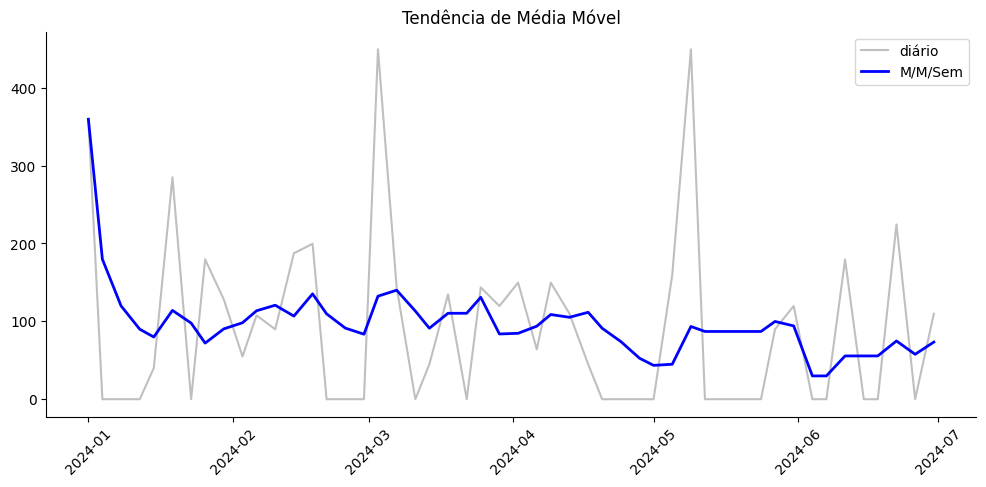

In [12]:
# Questão 2)

vends_dias = df.groupby("data")["total_venda"].sum().reset_index()
vends_dias["data"] = pd.to_datetime(vends_dias["data"])
vends_dias["mm7"] = vends_dias["total_venda"].rolling(7, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(vends_dias["data"], vends_dias["total_venda"], alpha=0.5, color="gray", label="diário")
plt.plot(vends_dias["data"], vends_dias["mm7"], color="#0000ff", linewidth=2, label="M/M/Sem")
plt.title("Tendência de Média Móvel")
plt.legend()
plt.xticks(rotation=45)
plt.show()


In [16]:
# Questão 3)

tckt_med = df.groupby("vendedor")["total_venda"].mean().sort_values(ascending=False).round(2)
print("\nRank de Ticket Médio por Vendedor:\n", tckt_med.apply(lambda x: f"R$ {x:,.2f}"))


Rank de Ticket Médio por Vendedor:
 vendedor
Fernanda Rocha    R$ 185.47
Bruno Costa       R$ 165.59
Carlos Mendes     R$ 156.88
Ana Lima          R$ 130.15
Name: total_venda, dtype: object


In [18]:
# Questão 4)

valormaisalto = df[df["total_venda"] > 200]
print(f"\nVendas > 200: {len(valormaisalto)} registros, R$ {valormaisalto['total_venda'].sum():,.2f}")
cat_alto = valormaisalto.groupby("categoria")["total_venda"].sum().sort_values(ascending=False)
print("Categorias:\n", cat_alto.apply(lambda x: f"R$ {x:,.2f}"))


Vendas > 200: 5 registros, R$ 1,768.10
Categorias:
 categoria
Tecnologia    R$ 1,543.60
Autoajuda       R$ 224.50
Name: total_venda, dtype: object


In [27]:
# Questão 5)

df_nulo = df.copy()
indcs = np.random.choice(df_nulo.index, 5, replace=False)
for i, idx in enumerate(indcs):
    col = ["quantidade","preco_unit","vendedor","regiao","total_venda"][i%5]
    df_nulo.loc[idx, col] = np.nan

print("Nulos Antes:\n", df_nulo.isnull().sum()[df_nulo.isnull().sum()>0])

df_nulo["quantidade"] = df_nulo["quantidade"].fillna(df_nulo["quantidade"].mean())
df_nulo["preco_unit"] = df_nulo["preco_unit"].fillna(df_nulo["preco_unit"].mean())
df_nulo["vendedor"] = df_nulo["vendedor"].fillna(df_nulo["vendedor"].mode()[0])
df_nulo["regiao"] = df_nulo["regiao"].fillna(df_nulo["regiao"].mode()[0])
df_nulo["total_venda"] = df_nulo.apply(lambda r: r["quantidade"]*r["preco_unit"] if pd.isna(r["total_venda"]) else r["total_venda"], axis=1)

print("\n")
print("Nulos Tratados!:\n")
print(df_nulo.isnull().sum()[df_nulo.isnull().sum()>0])

Nulos Antes:
 quantidade      1
preco_unit     22
vendedor        1
regiao          1
total_venda    22
dtype: int64


Nulos Tratados!:

Series([], dtype: int64)


###**Desafios Para Ir Além**
Depois de concluir o exercício base, tente resolver estes desafios para consolidar o aprendizado:

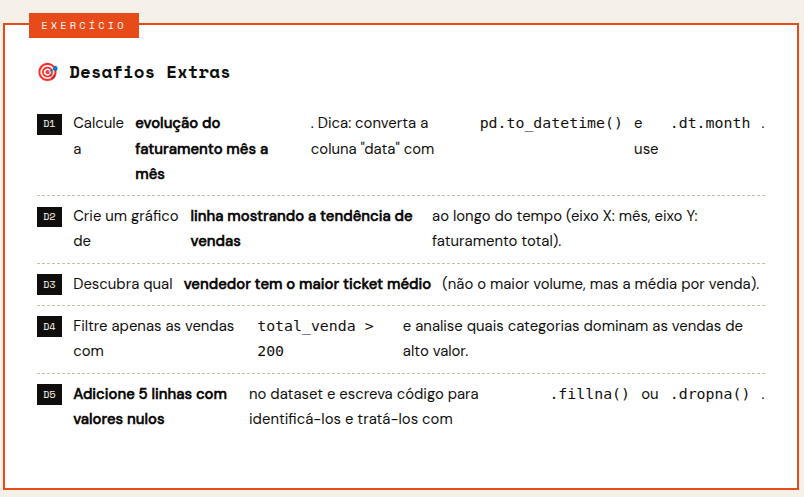